# Python 环境测试

本 notebook 用于快速自检当前 Jupyter 内核环境是否可用，依次检查：

1. 解释器版本与运行平台
2. 常用科学计算依赖库是否安装
3. 基础语法与容器运算
4. `matplotlib` 绘图能力
5. `pandas` 表格渲染
6. 本地文件读写权限

运行方式：在 VSCode 中打开本文件，点击 **全部运行（Run All）**，或等待自动执行结果。

In [1]:
import sys, platform, os, datetime

print("Python 版本 :", sys.version.replace("\n", " "))
print("版本号      :", platform.python_version())
print("解释器实现  :", platform.python_implementation())
print("操作系统    :", platform.system(), platform.release())
print("机器架构    :", platform.machine())
print("解释器路径  :", sys.executable)
print("工作目录    :", os.getcwd())
print("默认编码    :", sys.getdefaultencoding())
print("测试时间    :", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

Python 版本 : 3.6.4 |Anaconda, Inc.| (default, Jan 16 2018, 10:22:32) [MSC v.1900 64 bit (AMD64)]
版本号      : 3.6.4
解释器实现  : CPython
操作系统    : Windows 10
机器架构    : 
解释器路径  : C:\ProgramData\Anaconda3\python.exe
工作目录    : C:\Users\Administrator\WorkBuddy\2026-09-17-17-30-39\python-test
默认编码    : utf-8
测试时间    : 2026-09-17 17:37:16


In [2]:
packages = ["numpy", "pandas", "matplotlib", "scipy", "sklearn", "requests", "openpyxl"]

print("{:<12}{:<10}{}".format("依赖库", "状态", "版本"))
print("-" * 42)
for name in packages:
    try:
        mod = __import__(name)
        version = getattr(mod, "__version__", "未知")
        print("{:<12}{:<10}{}".format(name, "已安装", version))
    except Exception as exc:
        print("{:<12}{:<10}{}".format(name, "未安装", type(exc).__name__))

依赖库         状态        版本
------------------------------------------


numpy       已安装       1.14.0


pandas      已安装       0.22.0
matplotlib  已安装       2.1.2
scipy       已安装       1.0.0


sklearn     已安装       0.19.1


requests    已安装       2.18.4


openpyxl    已安装       2.4.10


In [3]:
# 基础数值与容器运算
a, b = 12, 5
print("a + b =", a + b, "| a * b =", a * b, "| a / b =", round(a / b, 3))

squares = {i: i ** 2 for i in range(1, 6)}
print("字典推导:", squares)

data = [3, 7, 1, 9, 4, 8]
print("列表:", data)
print("总和 =", sum(data), "| 最大值 =", max(data), "| 平均值 =", round(sum(data) / len(data), 2))

a + b = 17 | a * b = 60 | a / b = 2.4
字典推导: {1: 1, 2: 4, 3: 9, 4: 16, 5: 25}
列表: [3, 7, 1, 9, 4, 8]
总和 = 32 | 最大值 = 9 | 平均值 = 5.33


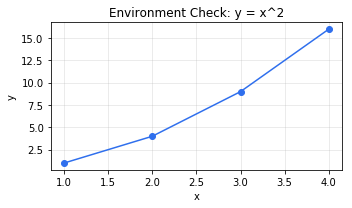

matplotlib 版本: 2.1.2


In [4]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(5, 3))
plt.plot([1, 2, 3, 4], [1, 4, 9, 16], marker="o", color="#2f6fed")
plt.title("Environment Check: y = x^2")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("matplotlib 版本:", matplotlib.__version__)

In [5]:
import pandas as pd

df = pd.DataFrame({
    "科目": ["语文", "数学", "英语", "物理"],
    "分数": [88, 95, 79, 92],
})
df["等级"] = df["分数"].apply(lambda s: "优" if s >= 90 else ("良" if s >= 80 else "中"))
df

,分数,科目,等级
0,88,语文,良
1,95,数学,优
2,79,英语,中
3,92,物理,优


In [6]:
import os, tempfile

test_dir = tempfile.mkdtemp(prefix="env_test_")
file_path = os.path.join(test_dir, "hello.txt")

with open(file_path, "w", encoding="utf-8") as fp:
    fp.write("环境测试写入成功\n")

with open(file_path, "r", encoding="utf-8") as fp:
    content = fp.read().strip()

print("临时目录:", test_dir)
print("文件存在:", os.path.exists(file_path))
print("读取内容:", content)

os.remove(file_path)
os.rmdir(test_dir)
print("清理完成:", not os.path.exists(test_dir))

临时目录: C:\Users\ADMINI~1\AppData\Local\Temp\env_test_lkwpftub
文件存在: True
读取内容: 环境测试写入成功
清理完成: True


## 测试结论

如果以上所有单元格均无红色报错，说明当前内核环境一切正常，可以开始正式的开发工作。

- 解释器与依赖库信息见第 1、2 个单元格
- 若某个依赖库显示「未安装」，可在终端执行 `pip install <库名>` 或 `conda install <库名>`
- 如需切换内核：VSCode 右上角点击内核名称 → 选择其他 Python 环境